# ResNet101 Waste Classifier (384px)

This notebook trains an ImageNet-pretrained ResNet101 on `dataset/standardized_384` for 10 waste categories (battery, biological, cardboard, clothes, glass, metal, paper, plastic, shoes, trash).

It saves the **last** checkpoint every epoch and the **best** checkpoint by validation accuracy (full training run, no early stopping), plots training vs validation loss and accuracy, and evaluates the best model on the test split with a printed confusion matrix and heatmap.


In [1]:
import os
import random
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from PIL import Image

from tqdm.auto import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch:", torch.__version__)
print("Torchvision:", __import__("torchvision").__version__)


@dataclass
class Config:
    data_dir: str = "dataset/standardized_384"
    img_size: int = 384
    batch_size: int = 16
    num_workers: int = 0
    epochs: int = 20
    lr: float = 3e-4
    weight_decay: float = 1e-4
    val_ratio: float = 0.10
    test_ratio: float = 0.10


cfg = Config()
print(cfg)


Device: cuda
Torch: 2.11.0+cu130
Torchvision: 0.26.0+cu130
Config(data_dir='dataset/standardized_384', img_size=384, batch_size=16, num_workers=0, epochs=20, lr=0.0003, weight_decay=0.0001, val_ratio=0.1, test_ratio=0.1)


/home/peter/Documents/IndividualProject5.0/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class WasteDataset(Dataset):
    """Dataset wrapper that applies transforms to (path, label) samples."""

    def __init__(self, samples, transform=None):
        self.samples = samples  # list of (image_path, label)
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, label


# Load all samples + class labels from ImageFolder
base_dataset = datasets.ImageFolder(cfg.data_dir)
class_names = base_dataset.classes
num_classes = len(class_names)
print("Classes:", class_names)
print("Num classes:", num_classes)

samples = base_dataset.samples  # (path, class_idx)
targets = np.array([label for _, label in samples], dtype=np.int64)

rng = np.random.default_rng(SEED)
train_samples, val_samples, test_samples = [], [], []

# Stratified split: 80% train / 10% val / 10% test per class
for class_idx in range(num_classes):
    class_indices = np.where(targets == class_idx)[0]
    rng.shuffle(class_indices)

    n_total = len(class_indices)
    n_train = int((1.0 - cfg.val_ratio - cfg.test_ratio) * n_total)
    n_val = int(cfg.val_ratio * n_total)
    n_test = n_total - n_train - n_val

    train_idx = class_indices[:n_train]
    val_idx = class_indices[n_train : n_train + n_val]
    test_idx = class_indices[n_train + n_val : n_train + n_val + n_test]

    train_samples.extend([samples[i] for i in train_idx])
    val_samples.extend([samples[i] for i in val_idx])
    test_samples.extend([samples[i] for i in test_idx])

print("Dataset sizes:")
print("  train:", len(train_samples))
print("  val:  ", len(val_samples))
print("  test: ", len(test_samples))

# ImageNet normalization (ResNet pretrained weights)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose(
    [
        transforms.Resize((cfg.img_size, cfg.img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.Resize((cfg.img_size, cfg.img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ]
)

train_ds = WasteDataset(train_samples, transform=train_transform)
val_ds = WasteDataset(val_samples, transform=eval_transform)
test_ds = WasteDataset(test_samples, transform=eval_transform)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    persistent_workers=(cfg.num_workers > 0),
    pin_memory=(device.type == "cuda"),
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    persistent_workers=(cfg.num_workers > 0),
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    persistent_workers=(cfg.num_workers > 0),
    pin_memory=(device.type == "cuda"),
)

print("DataLoaders ready.")


Classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
Num classes: 10
Dataset sizes:
  train: 9802
  val:   1221
  test:  1236
DataLoaders ready.


In [3]:
from torchvision.models import resnet101, ResNet101_Weights

weights = ResNet101_Weights.DEFAULT
model = resnet101(weights=weights)

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

print(model)
print("FC out_features:", model.fc.out_features)


Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /home/peter/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:02<00:00, 86.7MB/s] 


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
def confusion_metrics_from_cm(cm: np.ndarray):
    """Compute accuracy + weighted recall/F1 from a confusion matrix.

    cm shape: [num_classes, num_classes] where rows=true and cols=pred.
    """
    cm = cm.astype(np.int64)
    num_classes_local = cm.shape[0]

    total = cm.sum()
    correct = np.trace(cm)
    acc = float(correct / total) if total > 0 else 0.0

    support = cm.sum(axis=1)  # true count per class
    tp = np.diag(cm)
    pred_sum = cm.sum(axis=0)

    recall = np.divide(tp, support, out=np.zeros(num_classes_local, dtype=np.float64), where=support != 0)
    precision = np.divide(tp, pred_sum, out=np.zeros(num_classes_local, dtype=np.float64), where=pred_sum != 0)

    denom = precision + recall
    f1 = np.divide(
        2 * precision * recall,
        denom,
        out=np.zeros(num_classes_local, dtype=np.float64),
        where=denom != 0,
    )

    support_sum = support.sum()
    weighted_recall = float((recall * support).sum() / support_sum) if support_sum > 0 else 0.0
    weighted_f1 = float((f1 * support).sum() / support_sum) if support_sum > 0 else 0.0

    return acc, weighted_recall, weighted_f1


def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_batches = 0

    cm = np.zeros((num_classes, num_classes), dtype=np.int64)

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += float(loss.item())
            total_batches += 1

            preds = outputs.argmax(dim=1)
            preds_cpu = preds.detach().cpu().numpy()
            labels_cpu = labels.detach().cpu().numpy()
            for t, p in zip(labels_cpu, preds_cpu):
                cm[t, p] += 1

    avg_loss = total_loss / max(1, total_batches)
    acc, w_recall, w_f1 = confusion_metrics_from_cm(cm)
    return avg_loss, acc, w_recall, w_f1, cm


def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    total_batches = 0

    use_amp = device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    for inputs, labels in tqdm(loader, desc="Train", leave=False):
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        total_loss += float(loss.item())
        total_batches += 1

        preds = outputs.argmax(dim=1)
        total_correct += int((preds == labels).sum().item())
        total_samples += int(labels.shape[0])

    avg_loss = total_loss / max(1, total_batches)
    acc = float(total_correct / total_samples) if total_samples > 0 else 0.0
    return avg_loss, acc


best_val_acc = -1.0
best_epoch = -1

best_ckpt_path = "models/best_resnet101_384.pth"
last_ckpt_path = "models/last_resnet101_384.pth"

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_recall": [],
    "val_f1": [],
}

print("Starting training...")
for epoch in range(1, cfg.epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader)

    val_loss, val_acc, val_recall, val_f1, _ = evaluate(model, val_loader)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_recall"].append(val_recall)
    history["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch:02d}/{cfg.epochs} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, "
        f"val_recall(w)={val_recall:.4f}, val_f1(w)={val_f1:.4f}"
    )

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "class_names": class_names,
            "config": cfg.__dict__,
            "best_val_acc": best_val_acc,
        },
        last_ckpt_path,
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "class_names": class_names,
                "config": cfg.__dict__,
                "best_val_acc": best_val_acc,
                "val_recall": val_recall,
                "val_f1": val_f1,
            },
            best_ckpt_path,
        )

print(f"Training complete. Best val_acc={best_val_acc:.4f} at epoch {best_epoch}.")


Starting training...


Epoch 01/20 | train_loss=0.5296, train_acc=0.8329 | val_loss=0.3762, val_acc=0.8771, val_recall(w)=0.8771, val_f1(w)=0.8784


Epoch 02/20 | train_loss=0.2763, train_acc=0.9143 | val_loss=0.2766, val_acc=0.9197, val_recall(w)=0.9197, val_f1(w)=0.9202


Epoch 03/20 | train_loss=0.1932, train_acc=0.9382 | val_loss=0.2622, val_acc=0.9230, val_recall(w)=0.9230, val_f1(w)=0.9226


Epoch 04/20 | train_loss=0.1533, train_acc=0.9499 | val_loss=0.2437, val_acc=0.9222, val_recall(w)=0.9222, val_f1(w)=0.9227


...

Epoch 16/20 | train_loss=0.0028, train_acc=0.9995 | val_loss=0.1821, val_acc=0.9599, val_recall(w)=0.9599, val_f1(w)=0.9600


Epoch 17/20 | train_loss=0.0014, train_acc=0.9997 | val_loss=0.1903, val_acc=0.9607, val_recall(w)=0.9607, val_f1(w)=0.9609


Epoch 18/20 | train_loss=0.0004, train_acc=1.0000 | val_loss=0.1840, val_acc=0.9615, val_recall(w)=0.9615, val_f1(w)=0.9616


Epoch 19/20 | train_loss=0.0010, train_acc=0.9998 | val_loss=0.1934, val_acc=0.9607, val_recall(w)=0.9607, val_f1(w)=0.9608


Epoch 20/20 | train_loss=0.0004, train_acc=1.0000 | val_loss=0.1870, val_acc=0.9615, val_recall(w)=0.9615, val_f1(w)=0.9616
Training complete. Best val_acc=0.9615 at epoch 18.


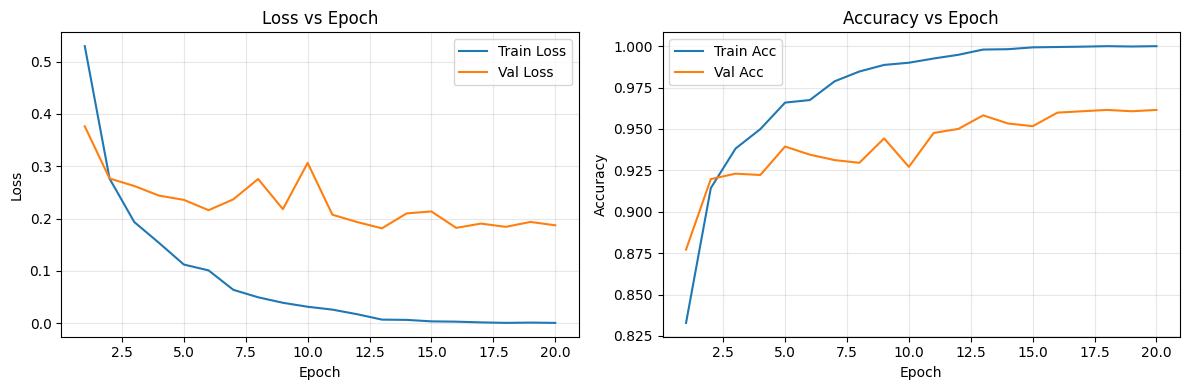

Best val_acc: 0.9615069615069615


In [5]:
# Plot training vs validation curves
epochs_range = list(range(1, cfg.epochs + 1))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Best val_acc:", max(history["val_acc"]))


Loading: best_resnet101_384.pth

Test results:
  loss=0.1983
  accuracy=0.9571
  weighted_recall=0.9571
  weighted_f1=0.9571

Confusion Matrix (rows=true, cols=predicted):
      batter biolog cardbo clothe  glass  metal  paper plasti  shoes  trash
batter     77      0      0      0      0      0      0      0      0      0
biolog      1     69      0      0      0      0      0      0      0      1
cardbo      1      0    134      0      1      1      3      1      0      1
clothe      0      0      0    189      0      0      1      0      0      0
 glass      0      1      1      0    165      1      1      5      0      1
 metal      2      0      1      1      1     86      0      2      0      0
 paper      1      0      5      0      0      0    126      1      1      1
plasti      0      0      2      1      4      1      0    150      0      3
 shoes      0      1      0      0      0      0      0      0    145      0
 trash      0      1      0      0      0      2      0    

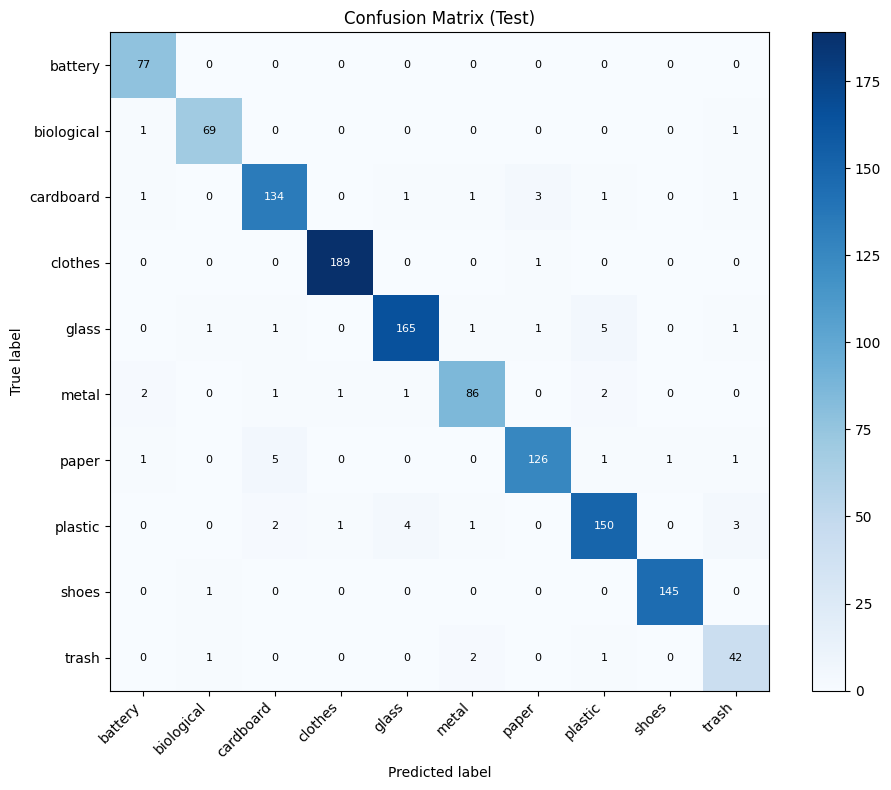

In [6]:
best_ckpt_path = "best_resnet101_384.pth"
print("Loading:", best_ckpt_path)

ckpt = torch.load(best_ckpt_path, map_location=device, weights_only=False)

weights = ResNet101_Weights.DEFAULT
best_model = resnet101(weights=weights)

in_features = best_model.fc.in_features
best_model.fc = nn.Linear(in_features, num_classes)

best_model.load_state_dict(ckpt["model_state_dict"], strict=True)
best_model = best_model.to(device)
best_model.eval()

class_names_ckpt = ckpt.get("class_names", class_names)

cm_test = np.zeros((num_classes, num_classes), dtype=np.int64)
total_loss = 0.0
total_batches = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = best_model(inputs)
        loss = criterion(outputs, labels)
        total_loss += float(loss.item())
        total_batches += 1

        preds = outputs.argmax(dim=1)

        preds_cpu = preds.detach().cpu().numpy()
        labels_cpu = labels.detach().cpu().numpy()

        for t, p in zip(labels_cpu, preds_cpu):
            cm_test[t, p] += 1

avg_test_loss = total_loss / max(1, total_batches)
test_acc, test_w_recall, test_w_f1 = confusion_metrics_from_cm(cm_test)

print("\nTest results:")
print(f"  loss={avg_test_loss:.4f}")
print(f"  accuracy={test_acc:.4f}")
print(f"  weighted_recall={test_w_recall:.4f}")
print(f"  weighted_f1={test_w_f1:.4f}")

print("\nConfusion Matrix (rows=true, cols=predicted):")

cell_width = 6
header = " " * cell_width + " ".join([name[:cell_width].rjust(cell_width) for name in class_names_ckpt])
print(header)
for i, true_name in enumerate(class_names_ckpt):
    row = [str(int(cm_test[i, j])).rjust(cell_width) for j in range(num_classes)]
    print(true_name[:cell_width].rjust(cell_width) + " " + " ".join(row))

plt.figure(figsize=(10, 8))
im = plt.imshow(cm_test, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix (Test)")
plt.colorbar(im)

tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, [n for n in class_names_ckpt], rotation=45, ha="right")
plt.yticks(tick_marks, [n for n in class_names_ckpt])

thresh = cm_test.max() / 2.0
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(
            j,
            i,
            str(int(cm_test[i, j])),
            ha="center",
            va="center",
            color="white" if cm_test[i, j] > thresh else "black",
            fontsize=8,
        )

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()
